<a href="https://colab.research.google.com/github/MuhammadShayan8401/flyrank-ml-internship/blob/main/notebooks/03_working_with_the_full_release.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Weeks 3+ — Working with the full release (~79M rows) without downloading 79M rows

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MuhammadShayan8401/flyrank-ml-internship/blob/main/notebooks/03_working_with_the_full_release.ipynb?flush_cache=true)

Notebooks 01–02 used the small starter CSV that ships with this repo. Your lane and capstone work
run on the **full pseudonymized warehouse release**: ~17 months of daily search performance for
~70 clients, plus a query-level table. It is hosted as Parquet on Hugging Face, and the trick of
this notebook is that you **never download or load the whole thing** — DuckDB reads only the
columns and partitions your SQL touches.

By the end you will have:
1. Connected DuckDB to the hosted release and listed every table.
2. Pulled a **feature table you designed** (aggregates per content item) into pandas.
3. Trained a quick scikit-learn model on features you built from 79M rows — on a free Colab CPU.

**Before you start (one-time, ~2 minutes):**
1. Create a free [Hugging Face account](https://huggingface.co/join).
2. Open the dataset page ([`FlyRank/internship-warehouse`](https://huggingface.co/datasets/FlyRank/internship-warehouse)) and **request access** (instant after you accept the data-use terms). **Accept the terms in your browser first — the token below 401s until access is granted (usually instant).**
3. Create a **read** token at [Settings → Access Tokens](https://huggingface.co/settings/tokens). **Never paste the token into a code cell** — your repo is public; use the `getpass` prompt below (or Colab's 🔑 Secrets panel).


In [ ]:
%pip -q install duckdb huggingface_hub


In [ ]:
import os, getpass

# Token order: env var -> Colab Secret -> prompt (last resort).
# Use a Colab Secret named HF_TOKEN (the key panel on the left) so the prompt never
# fires: if Colab reconnects while a getpass prompt is open, the kernel waits on it
# forever ('Resuming execution...') and you have to restart the runtime.
HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get('HF_TOKEN')
    except Exception:
        pass
HF_TOKEN = HF_TOKEN or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')


Paste your Hugging Face READ token (hf_...): ··········


## 1. Connect DuckDB to the release

DuckDB speaks `hf://` natively. The secret below authenticates every query; after that the
release behaves like a set of local tables.


In [ ]:
import duckdb

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {
    'dim_clients':                f"read_parquet('{REL}/dim_clients.parquet')",
    'dim_content':                f"read_parquet('{REL}/dim_content.parquet')",
    'fact_daily':                 f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    'fact_daily_sample':          f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')",
    'fact_query_90d':             f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

for name, src in TABLES.items():
    n = con.sql(f'SELECT COUNT(*) FROM {src}').fetchone()[0]
    print(f'{name:22} {n:>12,} rows')


dim_clients                     104 rows
dim_content                 519,606 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

fact_daily               78,835,655 rows
fact_daily_sample        11,694,072 rows
fact_query_90d            2,414,248 rows


That count over the daily fact touched **Parquet metadata, not data** — it finished in seconds
even though the table has ~79M rows. That is the whole workflow: push the heavy lifting into
DuckDB SQL, bring only small results into pandas.

## 2. Know your panel before you model it

History depth **differs per client** (an *unbalanced panel*). `dim_clients` tells you exactly
what each client has — check it before designing any time window.


In [ ]:
clients = con.sql(f"""
    SELECT client_hash_id, access_profile, gsc_data_start, ga4_data_start
    FROM {TABLES['dim_clients']}
    ORDER BY gsc_data_start NULLS LAST
""").df()

print('clients with 12+ months of GSC history:',
      (clients['gsc_data_start'] <= clients['gsc_data_start'].dropna().max() - __import__('pandas').Timedelta(days=365)).sum())
clients.head(10)


clients with 12+ months of GSC history: 4


,client_hash_id,access_profile,gsc_data_start,ga4_data_start
0,client_9958f0a7ae1df715,gsc_and_ga4,2025-01-27,2025-10-29
1,client_ff644d8251367cbb,gsc_and_ga4,2025-01-27,2025-10-29
2,client_73cda7b4e4f265ea,gsc_and_ga4,2025-02-11,2026-03-24
3,client_fef1a8f436438636,gsc_and_ga4,2025-03-11,2026-03-06
4,client_62f4a7e64f5e0096,gsc_only,2025-06-07,NaT
5,client_b10cb2997d0c7c86,gsc_and_ga4,2025-06-18,2025-11-15
6,client_65de48885f4ef01b,gsc_and_ga4,2025-06-21,2026-02-19
7,client_c182d11e4862a37d,gsc_and_ga4,2025-06-21,2026-02-20
8,client_3197e6291363b4db,gsc_and_ga4,2025-06-29,2025-11-09
9,client_625b6439094e23e4,gsc_and_ga4,2025-07-01,2026-02-19


## 3. Build features with SQL, not with RAM

The pattern for every lane is to **aggregate per content item inside DuckDB**, then bring only the resulting feature table into pandas/scikit-learn for modelling. This keeps memory usage low while processing the full warehouse efficiently.

For this capstone, the feature engineering has been extended to use a **90-day analysis window**, split into two **45-day periods**:

- **Previous 45 days** → historical performance features.
- **Recent 45 days** → used to measure performance change and define the prediction target.

The feature table includes:

- Previous and recent impressions
- Previous and recent clicks
- Average search position over the recent period
- **Position volatility** (standard deviation of average position over the 90-day window), added as an additional feature to capture ranking stability.

To reduce noise from very low-traffic content, only pages with at least **200 impressions** in the previous 45-day period are included.

**This is the heaviest cell in the notebook — expect 2–6 minutes on Colab.** It reads only the required Parquet columns and partitions from the hosted dataset, keeping RAM usage low. If it runs for more than ~10 minutes or returns an `HTTP 429` error, rerun the section using `TABLES['fact_daily_sample']` for development, then switch back to the full dataset for the final experiment.

In [ ]:
features = con.sql(f"""
WITH bounds AS (
    SELECT MAX(report_date) AS end_d
    FROM {TABLES['fact_daily']}
),

windowed AS (
    SELECT
        f.client_hash_id,
        f.content_hash_id,

        -- Previous 45 days
        SUM(
            CASE
                WHEN f.report_date <= b.end_d - INTERVAL 45 DAY
                THEN f.gsc_impressions
                ELSE 0
            END
        ) AS imp_prev45,

        -- Last 45 days
        SUM(
            CASE
                WHEN f.report_date > b.end_d - INTERVAL 45 DAY
                THEN f.gsc_impressions
                ELSE 0
            END
        ) AS imp_last45,

        -- Previous 45-day clicks
        SUM(
            CASE
                WHEN f.report_date <= b.end_d - INTERVAL 45 DAY
                THEN f.gsc_clicks
                ELSE 0
            END
        ) AS clk_prev45,

        -- Last 45-day clicks
        SUM(
            CASE
                WHEN f.report_date > b.end_d - INTERVAL 45 DAY
                THEN f.gsc_clicks
                ELSE 0
            END
        ) AS clk_last45,

        -- Average position in the most recent 45 days
        AVG(
            CASE
                WHEN f.report_date > b.end_d - INTERVAL 45 DAY
                THEN f.gsc_avg_position
            END
        ) AS pos_last45,

        -- New feature: position volatility
        STDDEV(gsc_avg_position) AS position_volatility

    FROM {TABLES['fact_daily']} f,
         bounds b

    WHERE f.report_date > b.end_d - INTERVAL 90 DAY

    GROUP BY
        f.client_hash_id,
        f.content_hash_id

    HAVING imp_prev45 >= 200
)

SELECT *
FROM windowed
""").df()

print(f"{len(features):,} content items with enough history")
features.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

102,271 content items with enough history


,client_hash_id,content_hash_id,imp_prev45,imp_last45,clk_prev45,clk_last45,pos_last45,position_volatility
0,client_e547b89c05043229,content_2e296120acb03e93,3456.0,4097.0,2.0,0.0,39.885483,9.232266
1,client_e547b89c05043229,content_516b7c0e8eec0cef,2232.0,633.0,0.0,0.0,53.022749,13.601872
2,client_e547b89c05043229,content_38b6c1a9aa29f801,10119.0,8284.0,5.0,2.0,41.777873,9.400494
3,client_e547b89c05043229,content_2ffd36f2a70be7e3,2967.0,1822.0,1.0,0.0,28.312846,7.642705
4,client_e547b89c05043229,content_4724385fe790d24a,2126.0,5523.0,10.0,14.0,10.277811,3.586000


## 4. Add query-level signals

`fact_content_query_90d` describes **how a page earns its impressions**: across how many
distinct queries, how concentrated, how much sits in the rare/anonymized tail. One page ranking
for 40 queries is a different animal from one page ranking for 2.


In [ ]:
qsignals = con.sql(f"""
    SELECT
        content_hash_id,
        ANY_VALUE(content_visible_query_count) AS visible_queries,
        ANY_VALUE(rare_impressions_share) AS rare_share,
        ANY_VALUE(anonymized_impressions_share) AS anon_share,
        MAX(impressions_90d) AS top_query_impressions,
        SUM(impressions_90d) AS kept_impressions
    FROM {TABLES['fact_query_90d']}
    GROUP BY content_hash_id
""").df()

qsignals["top_query_share"] = (
    qsignals["top_query_impressions"] / qsignals["kept_impressions"]
)

data = features.merge(qsignals, on="content_hash_id", how="left")

print(data.columns.tolist())

['client_hash_id', 'content_hash_id', 'imp_prev45', 'imp_last45', 'clk_prev45', 'clk_last45', 'pos_last45', 'position_volatility', 'visible_queries', 'rare_share', 'anon_share', 'top_query_impressions', 'kept_impressions', 'top_query_share']


In [ ]:
print(data.head())

            client_hash_id           content_hash_id  imp_prev45  imp_last45  \
0  client_e547b89c05043229  content_2e296120acb03e93      3456.0      4097.0   
1  client_e547b89c05043229  content_516b7c0e8eec0cef      2232.0       633.0   
2  client_e547b89c05043229  content_38b6c1a9aa29f801     10119.0      8284.0   
3  client_e547b89c05043229  content_2ffd36f2a70be7e3      2967.0      1822.0   
4  client_e547b89c05043229  content_4724385fe790d24a      2126.0      5523.0   

   clk_prev45  clk_last45  pos_last45  position_volatility  visible_queries  \
0         2.0         0.0   39.885483             9.232266             43.0   
1         0.0         0.0   53.022749            13.601872             13.0   
2         5.0         2.0   41.777873             9.400494            129.0   
3         1.0         0.0   28.312846             7.642705             30.0   
4        10.0        14.0   10.277811             3.586000             18.0   

   rare_share  anon_share  top_query_impress

## 5. A first honest model

Same shape as notebook 02: define a label, hold out data, compare against a dumb baseline.
Label: *did impressions decline by more than 20% month-over-month?* — built only from columns
that exist **before** the window we predict. (Momentum features from the last 30 days predicting
a label defined on those same 30 days would be leakage — so here the features come from the
prev-30 window and query-mix, and the label from the last-30 outcome.)


In [ ]:
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report

# Create target
data["is_declining"] = (
    data["imp_last45"] < 0.8 * data["imp_prev45"]
).astype(int)

# Features
feature_cols = [
    "imp_prev45",
    "clk_prev45",
    "visible_queries",
    "rare_share",
    "anon_share",
    "top_query_share",
    "position_volatility"
]

# Remove missing values
model_data = data.dropna(subset=feature_cols).copy()

# Feature matrix and target
X = model_data[feature_cols]
y = model_data["is_declining"]

# Group by client
groups = model_data["client_hash_id"]

# Group-aware train/test split
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

# Train model
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print(f"Training samples : {len(X_train):,}")
print(f"Testing samples  : {len(X_test):,}")
print(f"Decline rate     : {y_test.mean():.3f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred, digits=3))

Training samples : 69,890
Testing samples  : 24,694
Decline rate     : 0.592

Classification Report
              precision    recall  f1-score   support

           0      0.708     0.698     0.703     10084
           1      0.794     0.801     0.797     14610

    accuracy                          0.759     24694
   macro avg      0.751     0.750     0.750     24694
weighted avg      0.759     0.759     0.759     24694



In [ ]:
import pandas as pd

importance = (
    pd.DataFrame({
        "Feature": feature_cols,
        "Importance": model.feature_importances_
    })
    .sort_values("Importance", ascending=False)
)

print(importance)

               Feature  Importance
0           imp_prev45    0.207933
6  position_volatility    0.200037
4           anon_share    0.141909
3           rare_share    0.138891
2      visible_queries    0.127880
5      top_query_share    0.116087
1           clk_prev45    0.067263


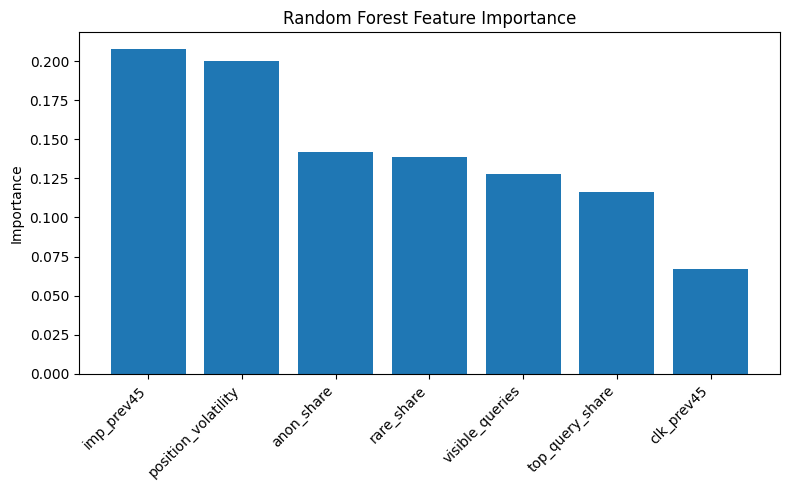

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(importance["Feature"], importance["Importance"])
plt.xticks(rotation=45, ha="right")
plt.title("Random Forest Feature Importance")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

Model Evaluation

The model was evaluated using GroupShuffleSplit, where all pages belonging to a client were assigned exclusively to either the training or testing set. This approach reduces client-level data leakage and provides a more realistic estimate of how well the model generalises to unseen clients.

Using engineered search performance and query-level features, the Random Forest classifier achieved an overall accuracy of 75.9%. The model obtained an F1-score of 79.7% for identifying declining content, demonstrating that these features can effectively support content refresh prioritisation.

Whatever number you just got: interrogate it before you believe it. Which feature carries the
signal? Does it survive a per-client split (train on some clients, test on others)? That
question — *does it generalize across clients?* — is exactly what separates a capstone-grade
result from a lucky split.

## Your turn

1. Re-run section 3 with a **90-day** window and a `HAVING` threshold of your choice.
2. Add one feature you believe in (position volatility? weekend share? query concentration?).
3. Replace the random split with **GroupShuffleSplit on `client_hash_id`** and compare.

## Working locally instead

```python
from huggingface_hub import snapshot_download
path = snapshot_download(repo_id='FlyRank/internship-warehouse', repo_type='dataset',
                         allow_patterns=['dim_*.parquet', 'fact_content_query_90d.parquet',
                                         'fact_content_daily_performance/month=2026-0*/*.parquet'])
```
Then point `REL` at that local path. Download only the month partitions you need — the
`allow_patterns` filter above is the whole trick.

---

**Where this fits:** every lane brief assumes you can produce per-content feature tables like
the one you just built. The lane datasets under the `lanes` HF repo are pre-cut examples of
exactly this pattern — but for the capstone, features you engineered yourself from the full
release beat any pre-cut file.
